# Метод K-ближайших соседей

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from functools import partial
from pathlib import Path
import warnings
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from research_utils.learning import grid_search, iteration_learning_score, get_top_n_info
from research_utils.plot import create_panel, plot_learning_curve, plot_complexity_and_accuracy, df_hist, df_scatter, series_hist, series_scatter
from research_utils.stats import agg_by_columns
from predictors.serialization import save_model
from predictors.feature_selection import ModelFeatureSelector
from predictors.metrics import exponential_weights, triangular_weights, gaussian_weights, quadratic_weights, rbf_weights
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_classif, chi2
from sklearn.preprocessing import PowerTransformer
from scipy import stats
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [34]:
models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

save = partial(save_model, models_dir)
train = pd.read_parquet("../data/processed/train.parquet")

## Подготовка данных
KNN имеет следующие допущения:
- Не требует нормальное распределение признаков, но может улучшить признаки
- Мульти-коррелированные признаки вредят модели (избыточные признаки)
- Крайне чувствительна к выбросам
- Требует единый масштаб признаков
- Сильно страдает от размерности

Таким образом, весь процесс предобработки будет похож на процесс предобработки логистической регресии

В качестве признаков будем использовать только непрерывные признаки (без флагов и комбинированных признаков)

Для сокращения размерности будем использовать SelectKBest

In [35]:
numeric_features = {
    'text__long_sentences_proportion', 
    'text__unpopular_words_proportion',
    'text__type_token_ratio',
    'text__mean_words_length',
    'text__lexicon_size',
    'entities__breadth_of_use_entities',
    'pos__mean_usage_NOUN', 
    'pos__mean_usage_PRON', 
    'pos__mean_usage_ADV',
    'pos__mean_usage_ADP', 
    'pos__mean_usage_SCONJ',
    'pos__mean_usage_CCONJ', 
    'pos__mean_usage_VERB',
    'pos__mean_usage_PROPN', 
    'pos__mean_usage_DET', 
    'pos__mean_usage_PART',
    "pos__ADJPOS_NOUN",
    "pos__PUNCT_SCONJ",
    "pos__ADP_ADJPOS",
    "pos__ADP_PRON",
    "pos__PUNCT_ADV",
    "pos__ADJPOS_PUNCT",
    "pos__PUNCT_CCONJ",
    'pos__index_of_formality_heylinger',
    'punct__breadth_of_use_puncts', 
    "punct__mean_usage_comma"
}
features_list = list(numeric_features)

In [ ]:
n_neighbors = [ 63, 87, 101, 127, 143, 169, 201, 215 ]
metrics = ['euclidean', 'manhattan', 'minkowski']
weights = [ 'uniform', 'distance', triangular_weights, gaussian_weights, quadratic_weights ]
n_numeric_features = [10, 13, 16, 18, 21, 'all']

pipeline_params = {
    'model__n_neighbors': n_neighbors,
    'model__metric': metrics,
    'model__weights': weights,
    'preprocessing__numeric__select_kbest__k': n_numeric_features,
}

numeric_fix_list = list(numeric_features.difference([
    "punct__breadth_of_use_puncts",
    "entities__breadth_of_use_entities",
    "pos__index_of_formality_heylinger",
    "text__type_token_ratio"
]))

def create_knn_pipeline(model_params=None):
    if not model_params:
        model_params = {}
    
    return Pipeline([
        ('get_features', ModelFeatureSelector(features_list)),
        
        ('power_transform', ColumnTransformer([
            ('numeric_power', PowerTransformer(method='yeo-johnson', standardize=False), 
             [features_list.index(f) for f in numeric_fix_list]),
        ], remainder='passthrough')),
        
        ('preprocessing', ColumnTransformer([
            ('numeric', Pipeline([
                ('scaler', RobustScaler()),
                ('select_kbest', SelectKBest(score_func=f_classif, k='all'))
            ]), [features_list.index(f) for f in numeric_features]),
            
        ], remainder='passthrough')),
        
        ('model', KNeighborsClassifier(**model_params))
    ])

## Независимые модели

### Классификатор пола

In [49]:
gender_pipeline = create_knn_pipeline()

gender_gs = grid_search(gender_pipeline, pipeline_params, train, train['gender'])

Fitting 5 folds for each of 720 candidates, totalling 3600 fits


In [50]:
gender_gs.best_params_, gender_gs.best_score_

({'model__metric': 'euclidean',
  'model__n_neighbors': 101,
  'model__weights': <function predictors.metrics.gaussian_weights(distances, sigma=1.0)>,
  'preprocessing__numeric__select_kbest__k': 21},
 np.float64(0.6496623376623376))

In [51]:
gender_top_5_info = get_top_n_info(gender_gs, n=5)
gender_top_5_info

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__metric,param_model__n_neighbors,param_model__weights,param_preprocessing__numeric__select_kbest__k,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
82,0.434445,0.028043,0.153900,0.008606,euclidean,101,<function gaussian_weights at 0x7c8fa9174540>,21,"{'model__metric': 'euclidean', 'model__n_neigh...",0.638442,0.645714,0.635844,0.658182,0.670130,0.649662,0.012837,1
562,0.429346,0.021379,0.158554,0.008590,minkowski,101,<function gaussian_weights at 0x7c8fa9174540>,21,"{'model__metric': 'minkowski', 'model__n_neigh...",0.638442,0.645714,0.635844,0.658182,0.670130,0.649662,0.012837,1
233,0.449589,0.040288,0.253174,0.009717,euclidean,215,<function gaussian_weights at 0x7c8fa9174540>,all,"{'model__metric': 'euclidean', 'model__n_neigh...",0.636883,0.655065,0.635844,0.658701,0.660779,0.649455,0.010849,3
713,0.406063,0.030747,0.250276,0.005044,minkowski,215,<function gaussian_weights at 0x7c8fa9174540>,all,"{'model__metric': 'minkowski', 'model__n_neigh...",0.636883,0.655065,0.635844,0.658701,0.660779,0.649455,0.010849,3
203,0.428693,0.030029,0.234093,0.010927,euclidean,201,<function gaussian_weights at 0x7c8fa9174540>,all,"{'model__metric': 'euclidean', 'model__n_neigh...",0.638961,0.655065,0.634286,0.657143,0.660260,0.649143,0.010460,5


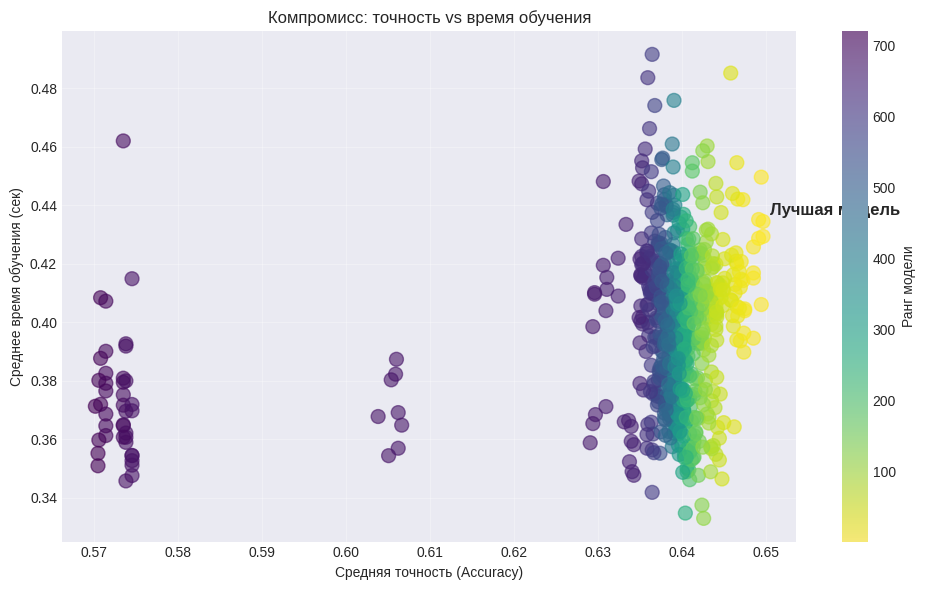

In [52]:
plot_complexity_and_accuracy(gender_gs)

In [54]:
gender_best_model_params = {
  'model__metric': 'euclidean',
  'model__n_neighbors': 101,
  'model__weights': gaussian_weights,
  'preprocessing__numeric__select_kbest__k': 21
}

gender_best_model = create_knn_pipeline()
gender_best_model.set_params(**gender_best_model_params)
gender_best_model_iter_learning_score = iteration_learning_score(gender_best_model, train, train['gender'])

In [55]:
alt_gender_model = create_knn_pipeline()
alt_gender_model.set_params(**
{
    'model__metric': 'euclidean',
    'model__n_neighbors': 101,
    'model__weights': gaussian_weights,
    'preprocessing__numeric__select_kbest__k': 'all'
}
)
alt_gender_model_iter_learning_score = iteration_learning_score(alt_gender_model, train, train['gender'])

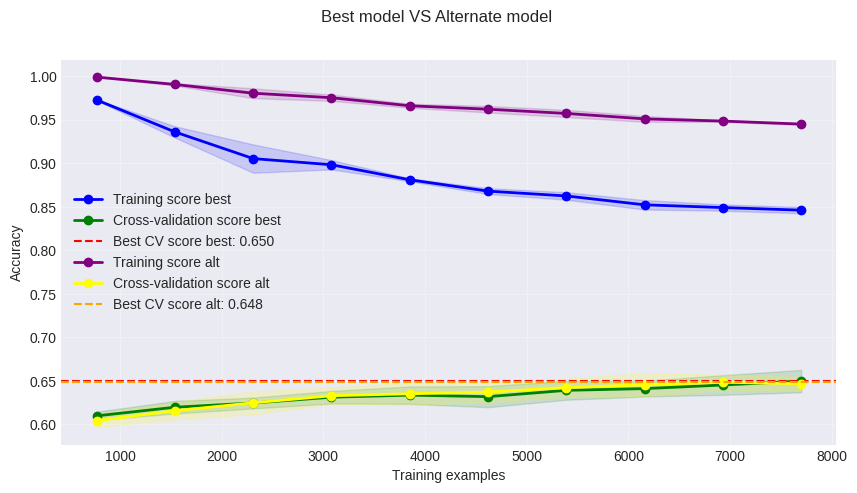

In [56]:
fig, axes = create_panel(1, cols=1, row_width=10)

plot_learning_curve(*gender_best_model_iter_learning_score, ax=axes.flat[0], name='best')
plot_learning_curve(*alt_gender_model_iter_learning_score, ax=axes.flat[0], name='alt', train_color="purple", val_color='yellow', score_color='orange')
plt.suptitle("Best model VS Alternate model")
plt.show()

Для сравнения использовались 2 конфигурации:
- Конфигурация с лучшим счетом по GS
- Конфигурация без отбора через KBest (все признаки - k=all)

Как видно по графику обучения, обе конфигурации видут себя схожим образом. Но конфигурация с отбором признаков меньше переобучается на обучающей выборке.

Лучший показатель - 65%

In [70]:
gender_best_model.fit(train, train['gender'])

model_params_serializable = gender_best_model_params.copy()
model_params_serializable['model__weights'] = model_params_serializable['model__weights'].__name__

save(
    gender_best_model, 
    "knn_gender_best", 
    model_params_serializable, 
    { "val": gender_best_model_iter_learning_score[2].tolist(), "train": gender_best_model_iter_learning_score[1].tolist() }
)

### Классификатор возраста

In [71]:
age_pipeline = create_knn_pipeline()

age_gs = grid_search(age_pipeline, pipeline_params, train, train['age'])

Fitting 5 folds for each of 720 candidates, totalling 3600 fits


In [72]:
age_gs.best_params_, age_gs.best_score_

({'model__metric': 'manhattan',
  'model__n_neighbors': 127,
  'model__weights': <function predictors.metrics.quadratic_weights(distances)>,
  'preprocessing__numeric__select_kbest__k': 'all'},
 np.float64(0.6007272727272728))

In [73]:
age_top_5_info = get_top_n_info(age_gs, n=5)
age_top_5_info

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__metric,param_model__n_neighbors,param_model__weights,param_preprocessing__numeric__select_kbest__k,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
359,0.374036,0.018897,0.454078,0.024244,manhattan,127,<function quadratic_weights at 0x7c8fa91745e0>,all,"{'model__metric': 'manhattan', 'model__n_neigh...",0.578182,0.600519,0.588052,0.618701,0.618182,0.600727,0.016104,1
389,0.376215,0.029529,0.449601,0.008257,manhattan,143,<function quadratic_weights at 0x7c8fa91745e0>,all,"{'model__metric': 'manhattan', 'model__n_neigh...",0.580260,0.602597,0.584935,0.621299,0.611429,0.600104,0.015541,2
347,0.360200,0.026298,0.445265,0.009047,manhattan,127,<function triangular_weights at 0x7c8fa91744a0>,all,"{'model__metric': 'manhattan', 'model__n_neigh...",0.578701,0.606234,0.584416,0.615584,0.613506,0.599688,0.015233,3
371,0.405662,0.040682,0.471327,0.009742,manhattan,143,distance,all,"{'model__metric': 'manhattan', 'model__n_neigh...",0.577662,0.595844,0.589091,0.616104,0.617143,0.599169,0.015395,4
341,0.374865,0.037678,0.444358,0.015863,manhattan,127,distance,all,"{'model__metric': 'manhattan', 'model__n_neigh...",0.577662,0.604156,0.583896,0.616104,0.612987,0.598961,0.015480,5


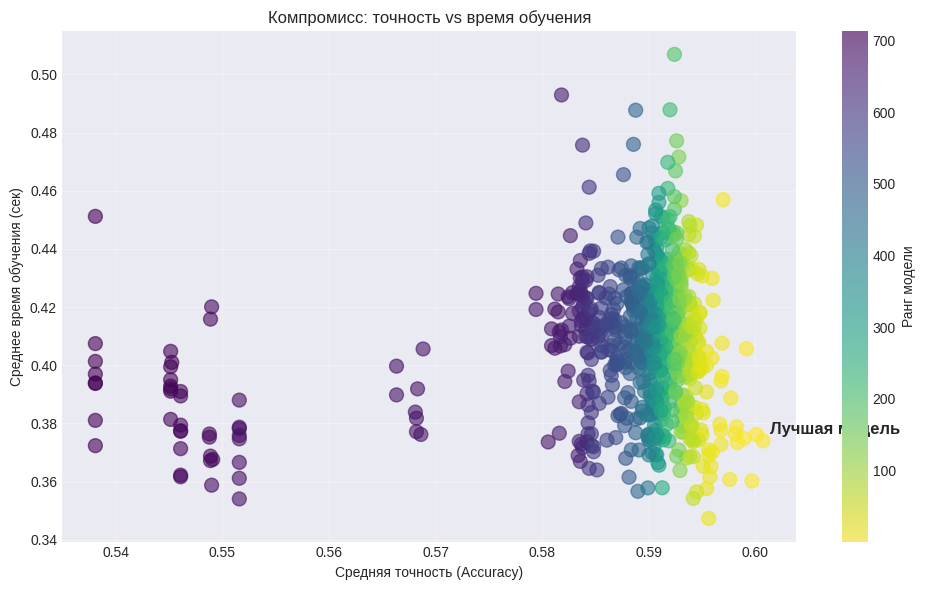

In [74]:
plot_complexity_and_accuracy(age_gs)

In [75]:
age_best_model_params = {
  'model__metric': 'manhattan',
  'model__n_neighbors': 127,
  'model__weights': quadratic_weights,
  'preprocessing__numeric__select_kbest__k': 'all'
}

age_best_model = create_knn_pipeline()
age_best_model.set_params(**age_best_model_params)
age_best_model_iter_learning_score = iteration_learning_score(age_best_model, train, train['age'])

In [76]:
alt_age_model = create_knn_pipeline()
alt_age_model.set_params(**
{
    'model__metric': 'euclidean',
    'model__n_neighbors': 101,
    'model__weights': gaussian_weights,
    'preprocessing__numeric__select_kbest__k': 21
}
)
alt_age_model_iter_learning_score = iteration_learning_score(alt_age_model, train, train['age'])

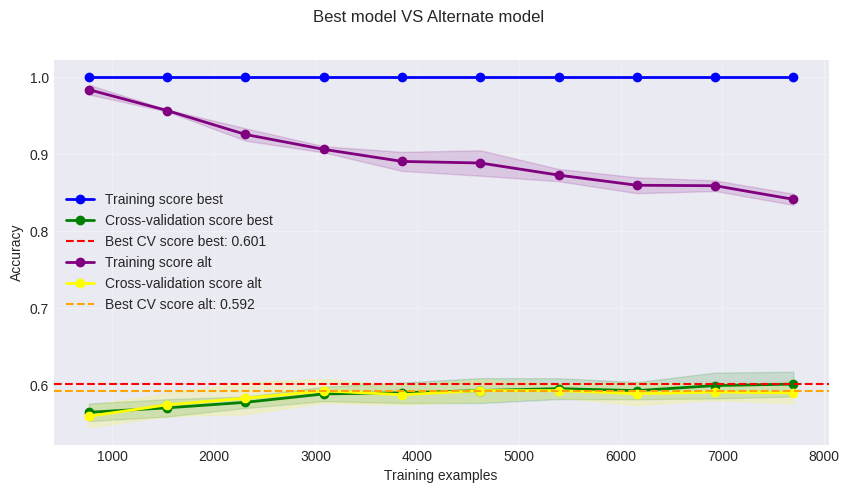

In [77]:
fig, axes = create_panel(1, cols=1, row_width=10)

plot_learning_curve(*age_best_model_iter_learning_score, ax=axes.flat[0], name='best')
plot_learning_curve(*alt_age_model_iter_learning_score, ax=axes.flat[0], name='alt', train_color="purple", val_color='yellow', score_color='orange')
plt.suptitle("Best model VS Alternate model")
plt.show()

Лучшая точность - 60.1%. 

In [78]:
age_best_model.fit(train, train['age'])

age_model_params_serializable = age_best_model_params.copy()
age_model_params_serializable['model__weights'] = age_model_params_serializable['model__weights'].__name__

save(
    age_best_model, 
    "knn_age_best", 
    age_model_params_serializable, 
    { "val": age_best_model_iter_learning_score[2].tolist(), "train": age_best_model_iter_learning_score[1].tolist() }
)

## Каскадный подход

Прогнозирование пола показывает более высокий показатель точности, по сравнению с прогнозирование возрастной группы. По этой причине сначала будет прогнозироваться пол, а затем в рамках пола - возраст

### Прогнозирование возраста мужчин

In [79]:
man_age_pipeline = create_knn_pipeline()

men_train = train[train['gender'] == 1]

men_age_gs = grid_search(man_age_pipeline, pipeline_params, men_train, men_train['age'])

Fitting 5 folds for each of 720 candidates, totalling 3600 fits


In [80]:
men_age_gs.best_params_, men_age_gs.best_score_

({'model__metric': 'manhattan',
  'model__n_neighbors': 143,
  'model__weights': <function predictors.metrics.quadratic_weights(distances)>,
  'preprocessing__numeric__select_kbest__k': 'all'},
 np.float64(0.6155611392130717))

In [81]:
men_age_top_5_info = get_top_n_info(men_age_gs, n=5)
men_age_top_5_info

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__metric,param_model__n_neighbors,param_model__weights,param_preprocessing__numeric__select_kbest__k,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
389,0.299678,0.022120,0.156385,0.006933,manhattan,143,<function quadratic_weights at 0x7c8fa91745e0>,all,"{'model__metric': 'manhattan', 'model__n_neigh...",0.622605,0.621648,0.604406,0.620326,0.608821,0.615561,0.007473,1
419,0.344563,0.023429,0.164006,0.006766,manhattan,169,<function quadratic_weights at 0x7c8fa91745e0>,all,"{'model__metric': 'manhattan', 'model__n_neigh...",0.613985,0.618774,0.609195,0.621285,0.613615,0.615371,0.004236,2
359,0.297681,0.015899,0.145130,0.001331,manhattan,127,<function quadratic_weights at 0x7c8fa91745e0>,all,"{'model__metric': 'manhattan', 'model__n_neigh...",0.620690,0.629310,0.609195,0.606903,0.610738,0.615367,0.008413,3
341,0.308830,0.017651,0.146242,0.003301,manhattan,127,distance,all,"{'model__metric': 'manhattan', 'model__n_neigh...",0.616858,0.630268,0.605364,0.612656,0.610738,0.615177,0.008401,4
365,0.293849,0.008842,0.149280,0.000703,manhattan,143,uniform,all,"{'model__metric': 'manhattan', 'model__n_neigh...",0.619732,0.618774,0.606322,0.618408,0.610738,0.614795,0.005320,5


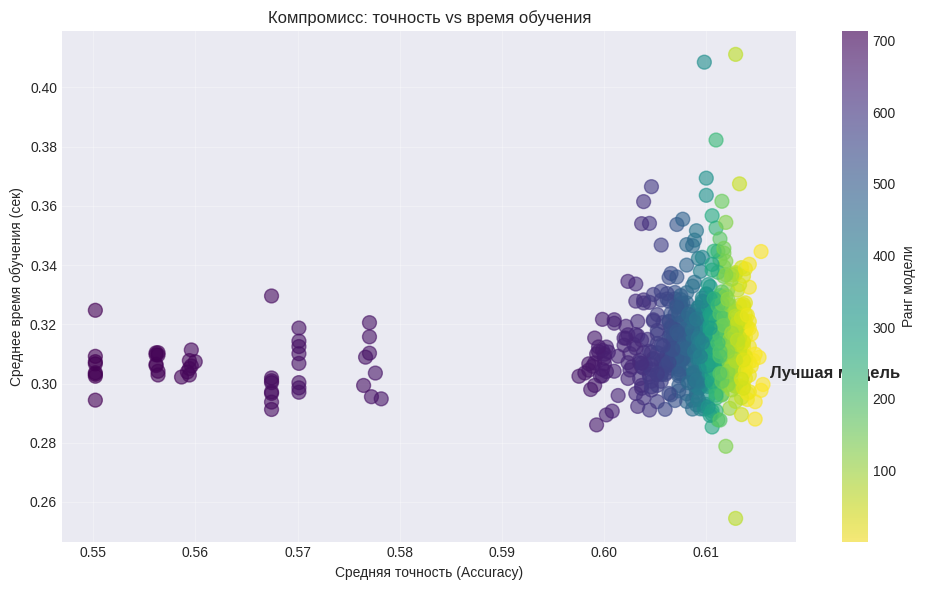

In [82]:
plot_complexity_and_accuracy(men_age_gs)

In [83]:
men_age_best_model_params = {
  'model__metric': 'manhattan',
  'model__n_neighbors': 143,
  'model__weights': quadratic_weights,
  'preprocessing__numeric__select_kbest__k': 'all'
}
men_age_best_model = create_knn_pipeline()
men_age_best_model.set_params(**men_age_best_model_params)
men_age_best_model_iter_learning_score = iteration_learning_score(men_age_best_model, men_train, men_train['age'])

In [84]:
alt_men_age_model = create_knn_pipeline()
alt_men_age_model.set_params(**
{
    'model__metric': 'euclidean',
    'model__n_neighbors': 101,
    'model__weights': gaussian_weights,
    'preprocessing__numeric__select_kbest__k': 21
}
)
alt_men_age_model_iter_learning_score = iteration_learning_score(alt_men_age_model, men_train, men_train['age'])

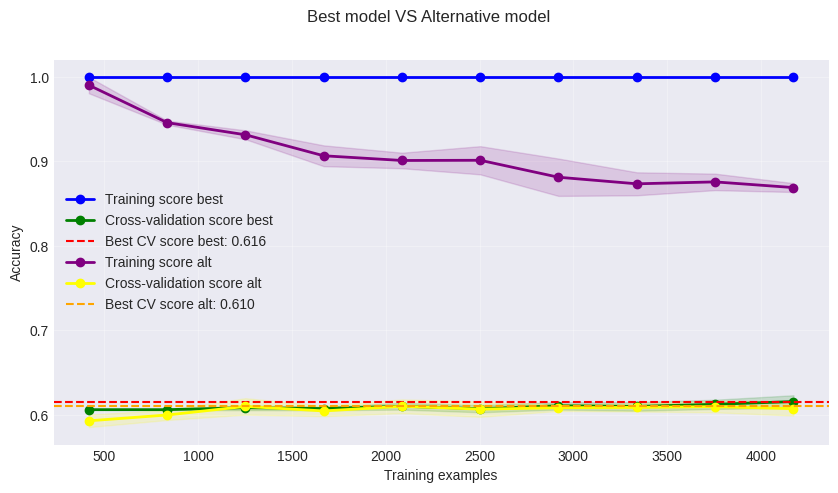

In [85]:
fig, axes = create_panel(1, cols=1, row_width=10)

plot_learning_curve(*men_age_best_model_iter_learning_score, ax=axes.flat[0], name='best')
plot_learning_curve(*alt_men_age_model_iter_learning_score, ax=axes.flat[0], name='alt', train_color="purple", val_color='yellow', score_color='orange')
plt.suptitle("Best model VS Alternative model")
plt.show()

Определение возраста в мужской подвыборке имеет точность на 1.5%, относительно общей модели

In [87]:
men_age_best_model.fit(men_train, men_train['age'])

men_age_model_params_serializable = age_best_model_params.copy()
men_age_model_params_serializable['model__weights'] = men_age_model_params_serializable['model__weights'].__name__

save(
    men_age_best_model, 
    "knn_men_age_best", 
    men_age_model_params_serializable, 
    { "val": men_age_best_model_iter_learning_score[2].tolist(), "train": men_age_best_model_iter_learning_score[1].tolist() }
)

### Прогнозирование возраста женщин

In [88]:
woman_age_pipeline = create_knn_pipeline()

women_train = train[train['gender'] == 0]

women_age_gs = grid_search(woman_age_pipeline, pipeline_params, women_train, women_train['age'])

Fitting 5 folds for each of 720 candidates, totalling 3600 fits


In [89]:
women_age_gs.best_params_, women_age_gs.best_score_

({'model__metric': 'euclidean',
  'model__n_neighbors': 87,
  'model__weights': 'distance',
  'preprocessing__numeric__select_kbest__k': 'all'},
 np.float64(0.653057106308282))

In [90]:
women_age_top_5_info = get_top_n_info(women_age_gs, n=5)
women_age_top_5_info

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__metric,param_model__n_neighbors,param_model__weights,param_preprocessing__numeric__select_kbest__k,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
41,0.314370,0.034338,0.056581,0.017127,euclidean,87,distance,all,"{'model__metric': 'euclidean', 'model__n_neigh...",0.642857,0.640590,0.652667,0.660613,0.668558,0.653057,0.010555,1
521,0.296678,0.025619,0.047505,0.001589,minkowski,87,distance,all,"{'model__metric': 'minkowski', 'model__n_neigh...",0.642857,0.640590,0.652667,0.660613,0.668558,0.653057,0.010555,1
59,0.321638,0.045534,0.049567,0.003819,euclidean,87,<function quadratic_weights at 0x7c8fa91745e0>,all,"{'model__metric': 'euclidean', 'model__n_neigh...",0.643991,0.642857,0.651532,0.657208,0.668558,0.652829,0.009443,3
539,0.285114,0.004154,0.048309,0.001701,minkowski,87,<function quadratic_weights at 0x7c8fa91745e0>,all,"{'model__metric': 'minkowski', 'model__n_neigh...",0.643991,0.642857,0.651532,0.657208,0.668558,0.652829,0.009443,3
58,0.308253,0.037072,0.050920,0.008525,euclidean,87,<function quadratic_weights at 0x7c8fa91745e0>,21,"{'model__metric': 'euclidean', 'model__n_neigh...",0.649660,0.642857,0.650397,0.661748,0.659478,0.652828,0.006916,5


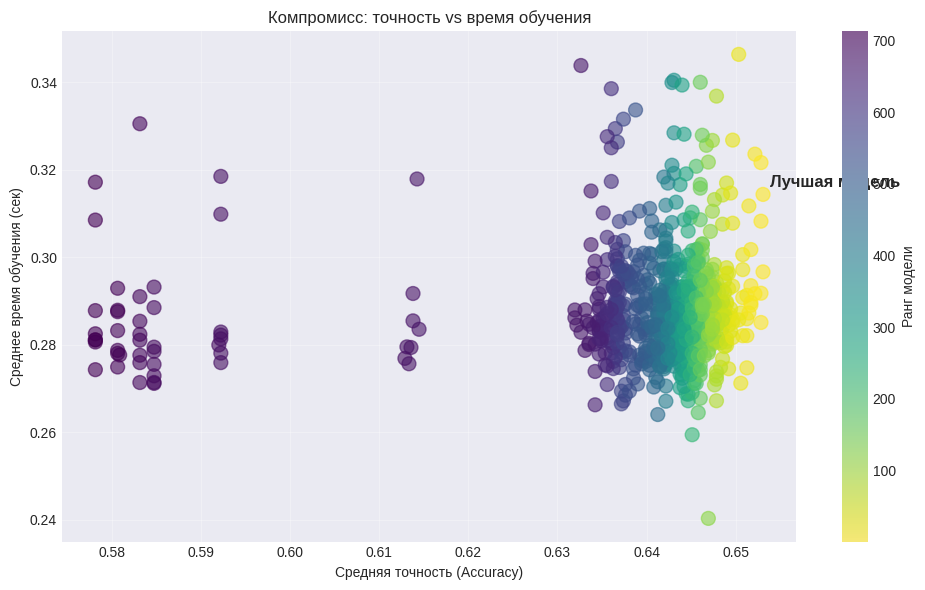

In [91]:
plot_complexity_and_accuracy(women_age_gs)

In [92]:
women_age_best_model_params = {
    'model__metric': 'euclidean',
    'model__n_neighbors': 87,
    'model__weights': 'distance',
    'preprocessing__numeric__select_kbest__k': 'all'
}
women_age_best_model = create_knn_pipeline()
women_age_best_model.set_params(**women_age_best_model_params)
women_age_best_model_iter_learning_score = iteration_learning_score(women_age_best_model, women_train, women_train['age'])

In [93]:
alt_women_age_model = create_knn_pipeline()
alt_women_age_model.set_params(**
{
    'model__metric': 'euclidean',
    'model__n_neighbors': 101,
    'model__weights': gaussian_weights,
    'preprocessing__numeric__select_kbest__k': 21
}
)
alt_women_age_model_iter_learning_score = iteration_learning_score(alt_women_age_model, women_train, women_train['age'])

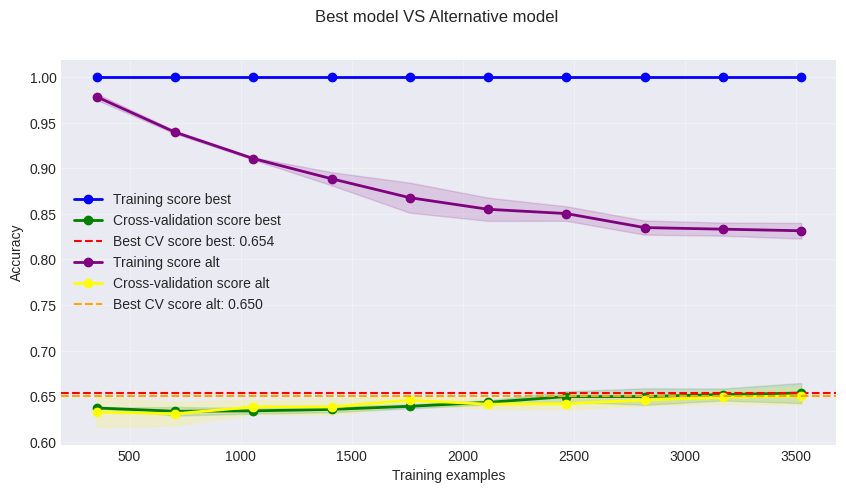

In [94]:
fig, axes = create_panel(1, cols=1, row_width=10)

plot_learning_curve(*women_age_best_model_iter_learning_score, ax=axes.flat[0], name='best')
plot_learning_curve(*alt_women_age_model_iter_learning_score, ax=axes.flat[0], name='alt', train_color="purple", val_color='yellow', score_color='orange')
plt.suptitle("Best model VS Alternative model")
plt.show()

Использование каскадного подхода позволило слегка улучшить качество прогнозирования с 60.1% до 61,6-65.4%. Каждая модель стала лучше разбираться в рамках своего пола

In [ ]:
women_age_best_model.fit(women_train, women_train['age'])

women_age_model_params_serializable = age_best_model_params.copy()
women_age_model_params_serializable['model__weights'] = women_age_model_params_serializable['model__weights'].__name__

save(
    women_age_best_model, 
    "knn_women_age_best", 
    women_age_model_params_serializable, 
    { "val": women_age_best_model_iter_learning_score[2].tolist(), "train": women_age_best_model_iter_learning_score[1].tolist() }
)

## Плоский подход

In [96]:
flat_y_train = train['gender'] * 2 + train['age']

In [97]:
flat_pipeline = create_knn_pipeline()

flat_gs = grid_search(flat_pipeline, pipeline_params, train, flat_y_train)

Fitting 5 folds for each of 720 candidates, totalling 3600 fits


In [98]:
flat_gs.best_params_, flat_gs.best_score_

({'model__metric': 'manhattan',
  'model__n_neighbors': 127,
  'model__weights': <function predictors.metrics.quadratic_weights(distances)>,
  'preprocessing__numeric__select_kbest__k': 'all'},
 np.float64(0.4287792207792207))

In [99]:
flat_top_5_info = get_top_n_info(flat_gs, n=5)
flat_top_5_info

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__metric,param_model__n_neighbors,param_model__weights,param_preprocessing__numeric__select_kbest__k,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
359,0.374464,0.017335,0.451161,0.011592,manhattan,127,<function quadratic_weights at 0x7c8fa91745e0>,all,"{'model__metric': 'manhattan', 'model__n_neigh...",0.420779,0.425974,0.419740,0.434286,0.443117,0.428779,0.008826,1
329,0.390152,0.033441,0.439558,0.018130,manhattan,101,<function quadratic_weights at 0x7c8fa91745e0>,all,"{'model__metric': 'manhattan', 'model__n_neigh...",0.421818,0.424416,0.417143,0.431169,0.444156,0.427740,0.009377,2
341,0.387443,0.018339,0.455752,0.021615,manhattan,127,distance,all,"{'model__metric': 'manhattan', 'model__n_neigh...",0.416104,0.425974,0.419221,0.436883,0.440000,0.427636,0.009433,3
299,0.388943,0.026941,0.425533,0.018239,manhattan,87,<function quadratic_weights at 0x7c8fa91745e0>,all,"{'model__metric': 'manhattan', 'model__n_neigh...",0.422857,0.419221,0.417662,0.431169,0.445195,0.427221,0.010130,4
347,0.403868,0.019926,0.471656,0.025608,manhattan,127,<function triangular_weights at 0x7c8fa91744a0>,all,"{'model__metric': 'manhattan', 'model__n_neigh...",0.411948,0.426494,0.418701,0.436883,0.441039,0.427013,0.010867,5


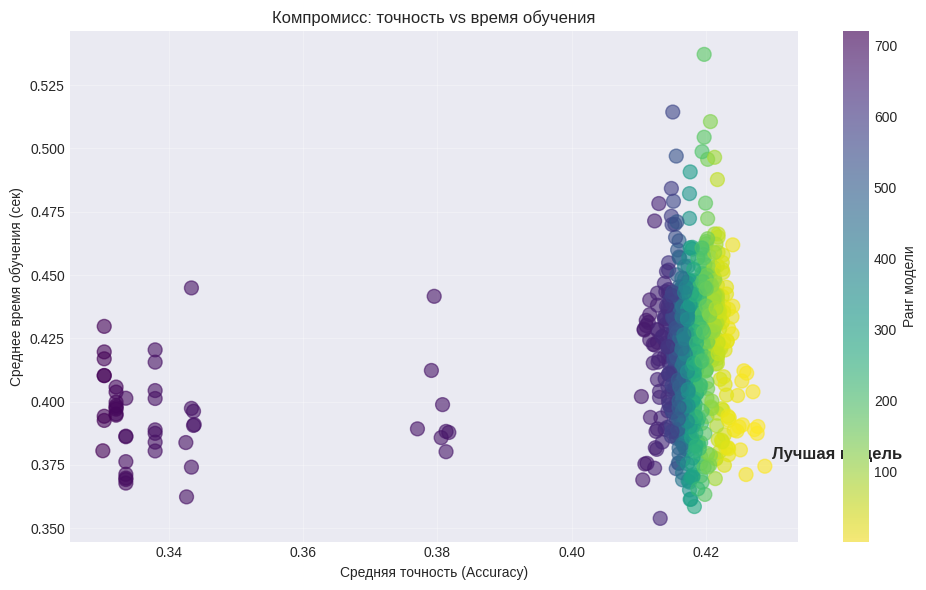

In [100]:
plot_complexity_and_accuracy(flat_gs)

In [101]:
flat_best_model_params = {
  'model__metric': 'manhattan',
  'model__n_neighbors': 127,
  'model__weights': quadratic_weights,
  'preprocessing__numeric__select_kbest__k': 'all'
}
flat_best_model = create_knn_pipeline()
flat_best_model.set_params(**flat_best_model_params)
flat_best_model_iter_learning_score = iteration_learning_score(flat_best_model, train, flat_y_train)

In [102]:
flat_alt_model = create_knn_pipeline()
flat_alt_model.set_params(**{
  'model__metric': 'manhattan',
  'model__n_neighbors': 127,
  'model__weights': quadratic_weights,
  'preprocessing__numeric__select_kbest__k': 10
})
flat_alt_model_iter_learning_score = iteration_learning_score(flat_alt_model, train, flat_y_train)

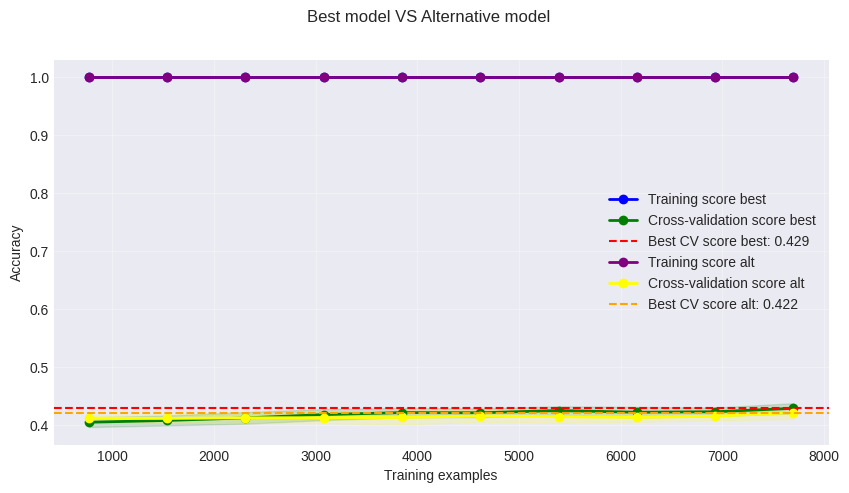

In [103]:
fig, axes = create_panel(1, cols=1, row_width=10)

plot_learning_curve(*flat_best_model_iter_learning_score, ax=axes.flat[0], name='best')
plot_learning_curve(*flat_alt_model_iter_learning_score, ax=axes.flat[0], name='alt', train_color="purple", val_color='yellow', score_color='orange')
plt.suptitle("Best model VS Alternative model")
plt.show()

Точность каскадного подхода приблизительно составит `0.650 * 0.616 = 0.400`. Плоский подход превосходит эту приблизительную точность на 3% процента.

In [104]:
flat_best_model.fit(train, flat_y_train)

flat_model_params_serializable = age_best_model_params.copy()
flat_model_params_serializable['model__weights'] = flat_model_params_serializable['model__weights'].__name__

save(
    flat_best_model, 
    "knn_flat_best", 
    flat_model_params_serializable, 
    { "val": flat_best_model_iter_learning_score[2].tolist(), "train": flat_best_model_iter_learning_score[1].tolist() }
)